In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import cohen_kappa_score
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

In [2]:
#File Upload
df=pd.read_csv("bank-additional-full.csv", sep=';')

In [3]:
# 3. Drop Leakage Feature
df.drop('duration', axis=1, inplace=True)

In [4]:
# 4. Handle "unknown" Values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

In [5]:
# 5. Encode Target
df['y'] = df['y'].map({'no': 0, 'yes': 1})
# 6. One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)
X_shuffled = df.drop('y', axis=1)
y_shuffled = df['y']

In [6]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

# Split
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, test_size=0.2, random_state=42)

In [7]:
# Model
from sklearn.ensemble import RandomForestClassifier
model1 = RandomForestClassifier()

# Search space
param_dist2 = {
         "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

In [8]:
# RandomForestClassifier

random_search = RandomizedSearchCV(model1, param_distributions=param_dist2, n_iter=15,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best CV accuracy: 0.9017
Test accuracy: 0.8971



SHAP EXPLANATION STARTED


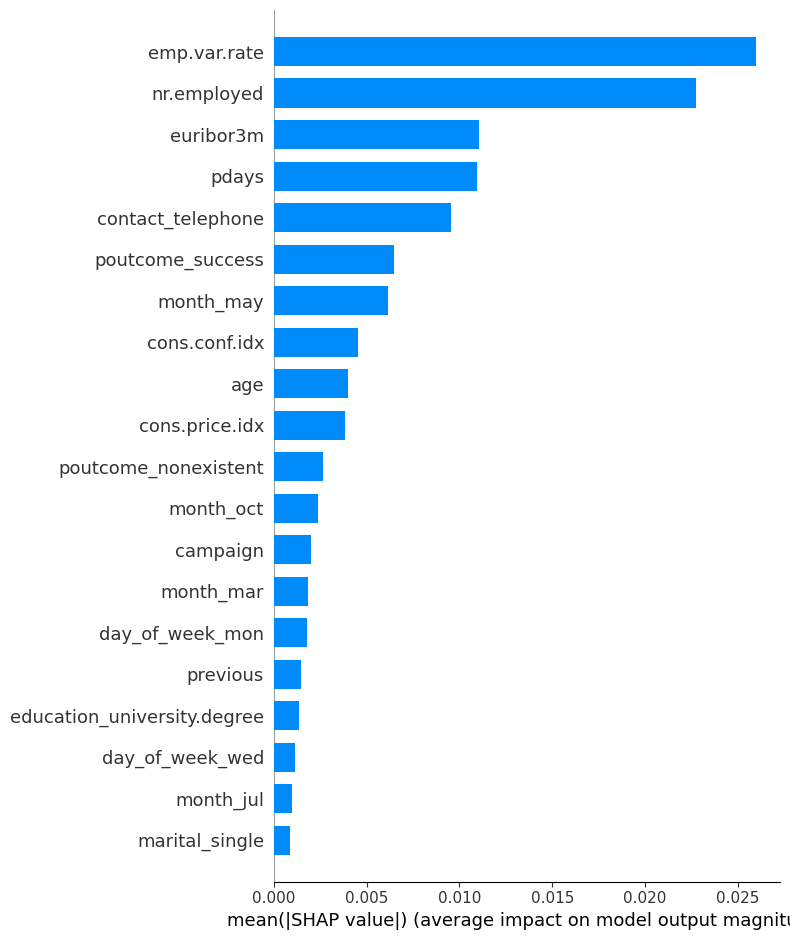

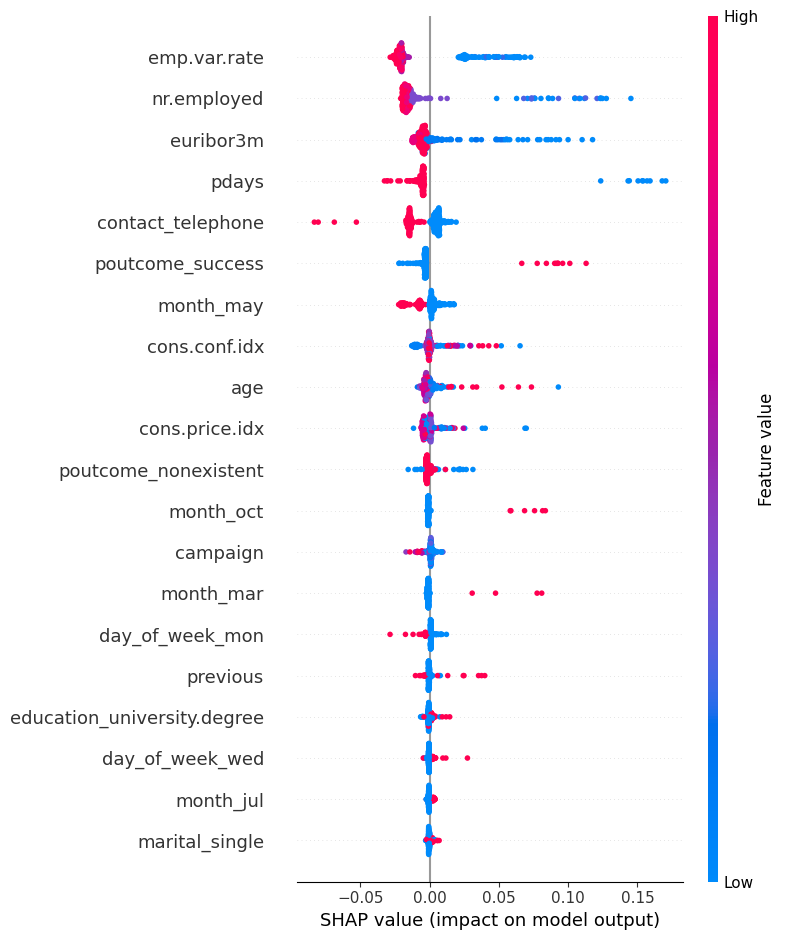

<Figure size 640x480 with 0 Axes>

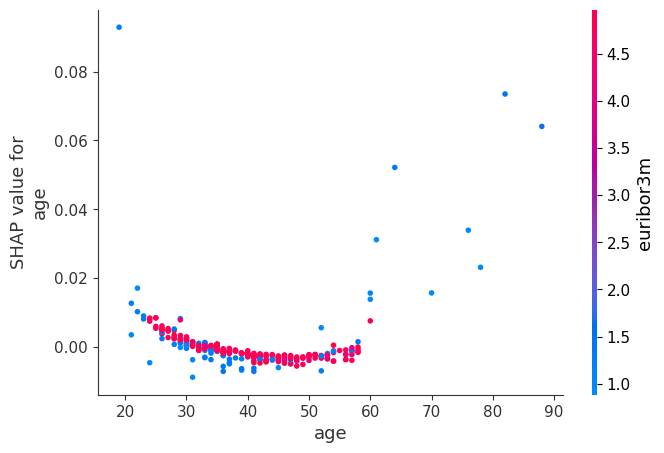

<Figure size 640x480 with 0 Axes>

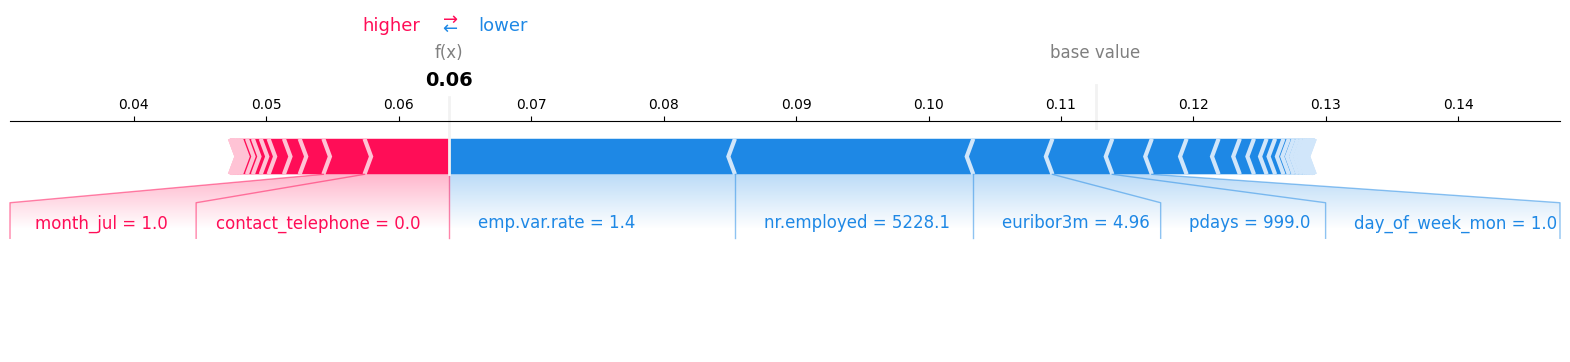

In [9]:
import shap
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION STARTED")

# take small sample (SHAP slow on full data)
X_sample = X_train.sample(300, random_state=42)

# TreeExplainer for tree models
explainer = shap.TreeExplainer(best_model_LR)

# compute SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification -> class 1
shap_vals = shap_values[:,:,1]

#  Global importance (bar)
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar", show=False)
plt.savefig("SHAP_Bar.png", bbox_inches="tight")
plt.show()

#  Beeswarm Summary
plt.figure()
shap.summary_plot(shap_vals, X_sample, show=False)
plt.savefig("SHAP_Beeswarm.png", bbox_inches="tight")
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(X_sample.columns[0], shap_vals, X_sample, show=False)
plt.savefig("SHAP_Dependence.png", bbox_inches="tight")
plt.show()

#  Local Force Plot (STATIC)
plt.figure()
shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_sample.iloc[0],
    matplotlib=True,
    show=False
)
plt.savefig("SHAP_Force.png", bbox_inches="tight")
plt.show()


LIME STARTED 
Creating Local LIME...


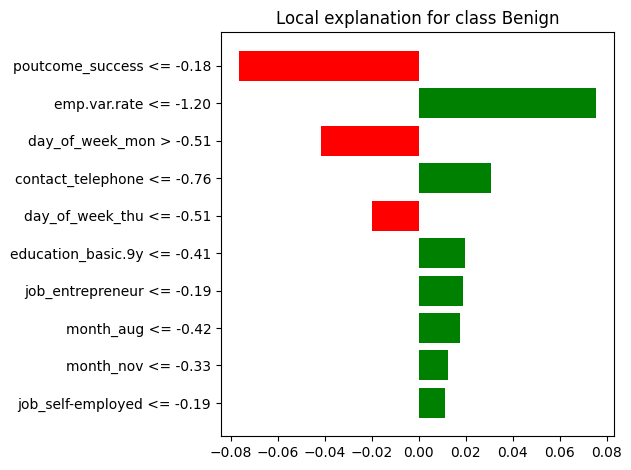

LIME COMPLETED 


In [10]:
from sklearn.preprocessing import StandardScaler
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("LIME STARTED ")

#  SCALE DATA (important for LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


#  CREATE LIME EXPLAINER
lime_explainer = LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X_train.columns.tolist(),
    class_names   = ['Malignant','Benign'],
    mode          = 'classification',
    discretize_continuous = True
)

#  LOCAL LIME (Single Prediction)
print("Creating Local LIME...")

i = 0   # first test row

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    best_model_LR.predict_proba,
    num_features = 10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("LIME_Local_RF.png", dpi=300)
plt.show()
print("LIME COMPLETED ")

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (Random Forest)
from sklearn.ensemble import RandomForestClassifier
clf_name = "Random Forest"
clf = RandomForestClassifier()



# Store results
results1 = []

# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results1.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results1_df1 = pd.DataFrame(results1)

# Print
print(f"Results for {clf_name}:")
print(results1_df1)

# Save to CSV if needed
results1_df1.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for Random Forest:
   Fold     Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0     1  Random Forest  0.891964   0.530909  0.316017     0.964725  0.396201   
1     2  Random Forest  0.888565   0.530435  0.257928     0.970378  0.347084   
2     3  Random Forest  0.897548   0.568376  0.292952     0.972442  0.386628   
3     4  Random Forest  0.889779   0.519084  0.293103     0.965527  0.374656   
4     5  Random Forest  0.887594   0.489051  0.293217     0.961770  0.366621   
5     6  Random Forest  0.884681   0.554307  0.293651     0.967082  0.383917   
6     7  Random Forest  0.897305   0.516588  0.253488     0.972350  0.340094   
7     8  Random Forest  0.898519   0.561475  0.305804     0.970853  0.395954   
8     9  Random Forest  0.888052   0.506383  0.256466     0.968254  0.340486   
9    10  Random Forest  0.889509   0.551601  0.320248     0.965327  0.405229   

         GM       FPR       AUC       MCC     Kappa  Balanced Accuracy  \
0  0.552150  0.035

In [12]:
# Model
from sklearn.neighbors import KNeighborsClassifier
model2 = KNeighborsClassifier()

# Search space
param_dist3 = {
         "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
}

In [13]:
# KNeighbors Classifier

random_search = RandomizedSearchCV(model2, param_distributions=param_dist3, n_iter=25,
                                   cv=15, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'weights': 'uniform', 'n_neighbors': 7}
Best CV accuracy: 0.8120
Test accuracy: 0.8919



SHAP EXPLANATION 


100%|██████████| 10/10 [01:00<00:00,  6.07s/it]


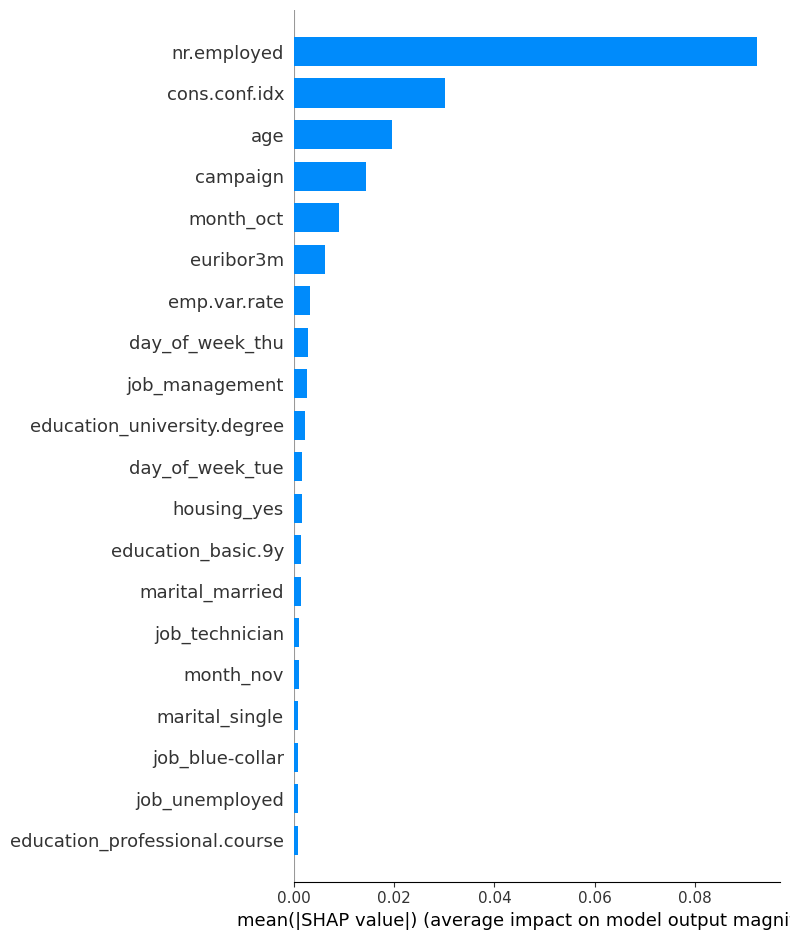

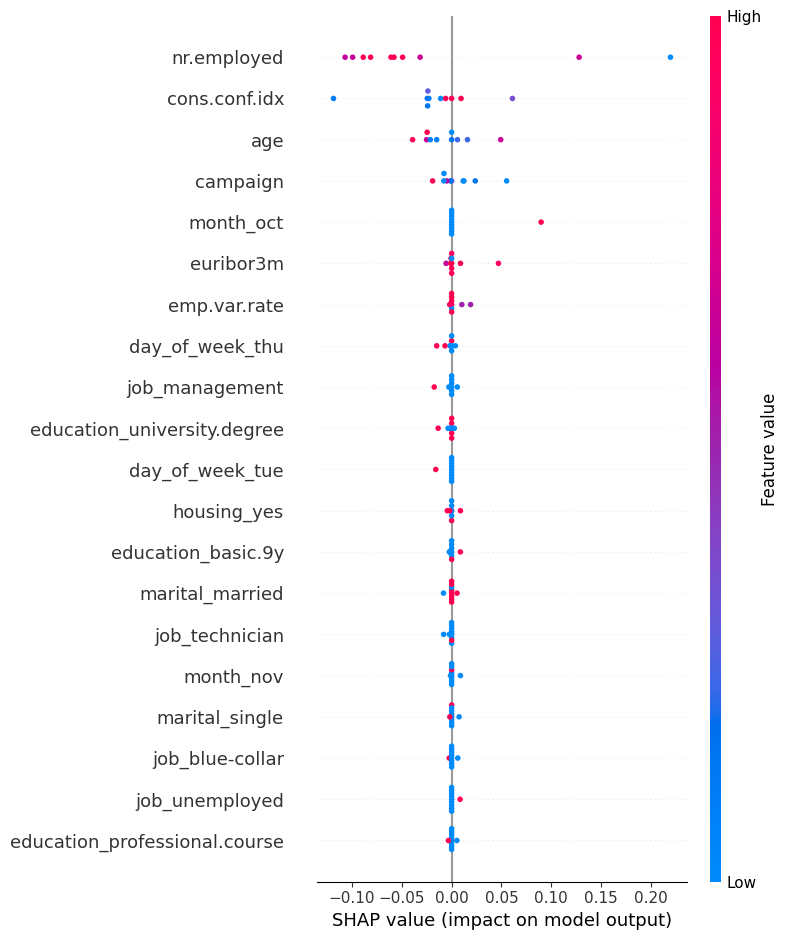

<Figure size 640x480 with 0 Axes>

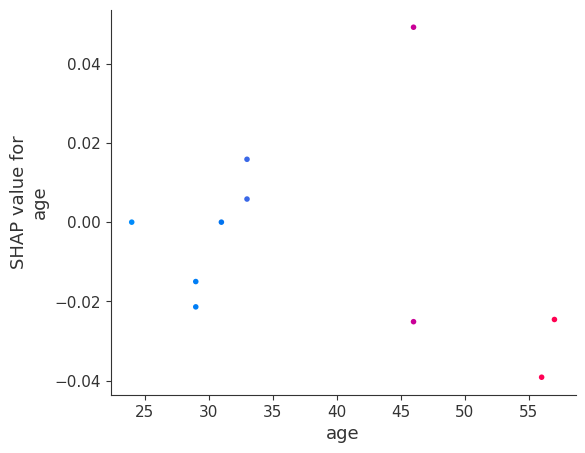

<Figure size 640x480 with 0 Axes>

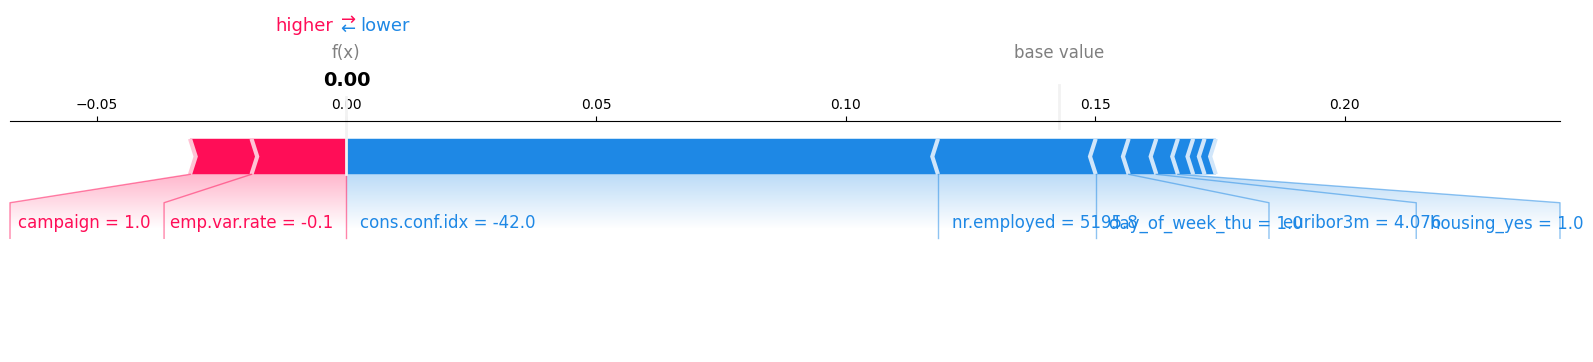

SHAP COMPLETED


In [14]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION ")

# SHAP slow → small background
X_sample = X_train.sample(20, random_state=42)
X_test_sample = X_test.sample(10, random_state=42)

# KernelExplainer needs prediction function
def predict_fn(data):
    return best_model_LR.predict_proba(data)

explainer = shap.KernelExplainer(predict_fn, X_sample)

# calculate shap values
shap_values = explainer.shap_values(X_test_sample)

# binary classification → class 1
shap_vals = shap_values[:,:,1]

# Global Feature Importance (BAR)
plt.figure()
shap.summary_plot(shap_vals, X_test_sample, plot_type="bar", show=False)
plt.savefig("KNN_SHAP_bar.png", bbox_inches='tight')
plt.show()

#  Global Beeswarm
plt.figure()
shap.summary_plot(shap_vals, X_test_sample, show=False)
plt.savefig("KNN_SHAP_beeswarm.png", bbox_inches='tight')
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(X_train.columns[0], shap_vals, X_test_sample, show=False)
plt.savefig("KNN_SHAP_dependence.png", bbox_inches='tight')
plt.show()

# Local Explanation (force plot static)
plt.figure()
shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_test_sample.iloc[0],
    matplotlib=True,
    show=False
)
plt.savefig("KNN_SHAP_force.png", bbox_inches='tight')
plt.show()

print("SHAP COMPLETED")


LIME EXPLANATION STARTED

Prediction probability: [[0.71428571 0.28571429]]


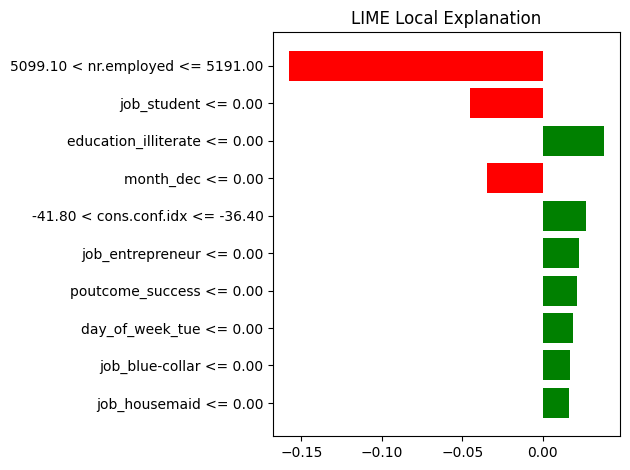


LIME COMPLETED


In [15]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
print("\nLIME EXPLANATION STARTED")

# convert dataframe → numpy (LIME needs numpy)
X_train_np = X_train.values.astype(np.float64)
X_test_np  = X_test.values.astype(np.float64)
scaler=scaler.fit(X_train)
#wrapper for scaled prediction
def predict_fn(x):
    x=np.array(x).astype(float)
    return best_model_LR.predict_proba(x)
# create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_np,
    feature_names = X_train.columns.tolist(),
    class_names   = ["Class 0","Class 1"],   # change if needed
    mode          = "classification",
    discretize_continuous=True,
    sample_around_instance=True
)

#  LOCAL EXPLANATION (single prediction)
i = 0   # choose test sample index

exp = explainer.explain_instance(
    data_row   = X_test_np[i],
    predict_fn = predict_fn,
    num_features=10
)

print("\nPrediction probability:",predict_fn([X_test_np[i]]))

# save static plot (GitHub friendly)
fig = exp.as_pyplot_figure()
plt.title("LIME Local Explanation")
plt.tight_layout()
plt.savefig("LIME_Local_Explanation.png", dpi=300)
plt.show()

print("\nLIME COMPLETED")

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (KNN)
from sklearn.neighbors import KNeighborsClassifier
clf_name = "KNN"
clf = KNeighborsClassifier()

# Store results
results2 = []




# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results2.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results2_df2 = pd.DataFrame(results2)

# Print
print(f"Results for {clf_name}:")
print(results2_df2)

# Save to CSV if needed
results2_df2.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for KNN:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1        KNN  0.891479   0.564706  0.300000     0.969497  0.391837   
1      2        KNN  0.887473   0.508772  0.278846     0.965489  0.360248   
2      3        KNN  0.887473   0.482558  0.273927     0.963569  0.349474   
3      4        KNN  0.900947   0.608187  0.336570     0.972507  0.433333   
4      5        KNN  0.888929   0.506944  0.237785     0.970890  0.323725   
5      6        KNN  0.893299   0.525140  0.311258     0.965221  0.390852   
6      7        KNN  0.887837   0.448864  0.272414     0.960505  0.339056   
7      8        KNN  0.879097   0.510753  0.282738     0.962241  0.363985   
8      9        KNN  0.886744   0.569767  0.292537     0.969307  0.386588   
9     10        KNN  0.887473   0.484848  0.263158     0.965192  0.341151   
10    11        KNN  0.902403   0.543046  0.291815     0.972008  0.379630   
11    12        KNN  0.894028   0.505208  0.331058     0.96

In [18]:
# Model
from sklearn.svm import LinearSVC
model3 = LinearSVC()
param_dist4 = {
    "C": [0.01, 0.1, 1, 10],
    "loss": ["hinge", "squared_hinge"],
    "max_iter": [1000, 2000]
}

In [19]:
# LinearSVC

random_search = RandomizedSearchCV(model3, param_distributions=param_dist4, n_iter=10,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'max_iter': 1000, 'loss': 'squared_hinge', 'C': 0.01}
Best CV accuracy: 0.8455
Test accuracy: 0.8980



  SHAP EXPLANATION 


100%|██████████| 100/100 [03:34<00:00,  2.15s/it]


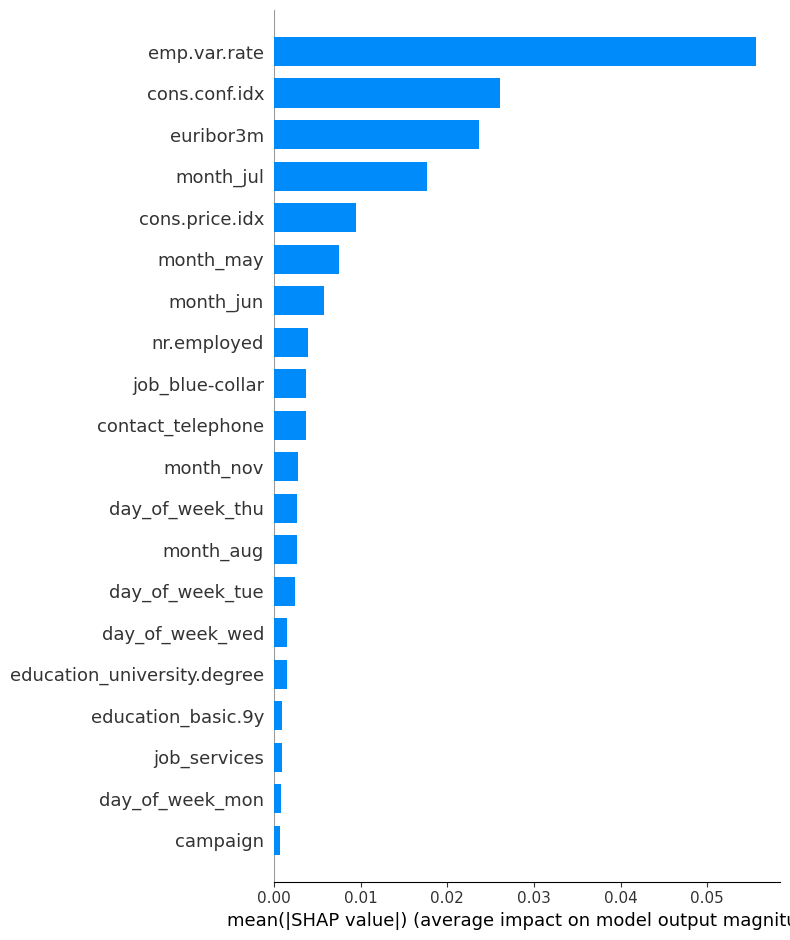

<Figure size 640x480 with 0 Axes>

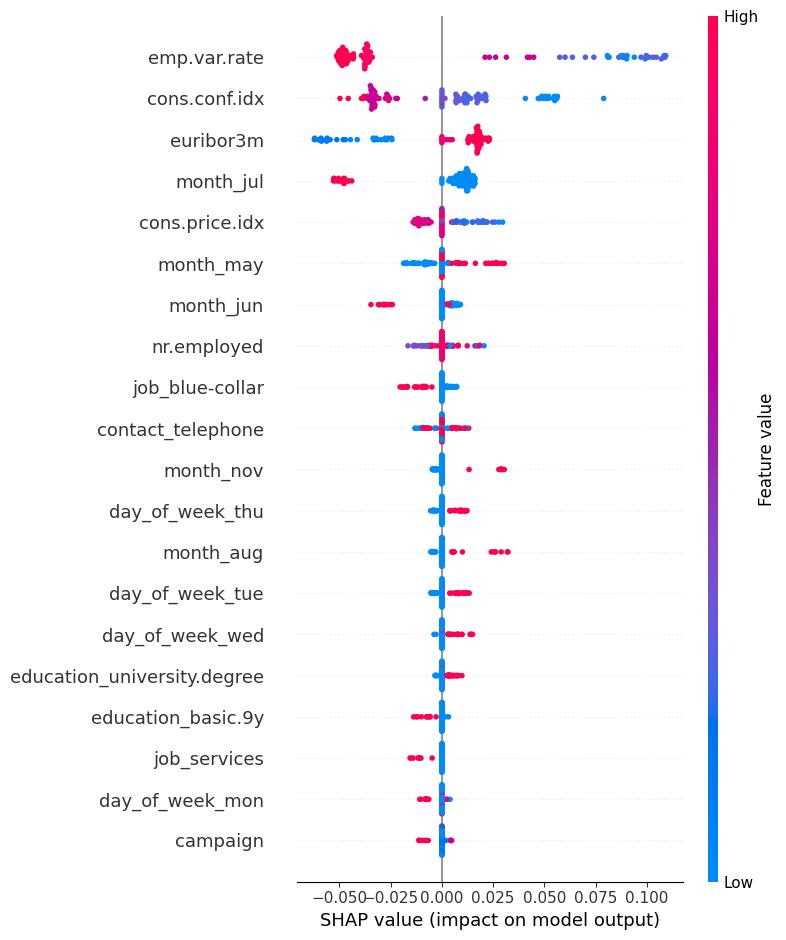

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

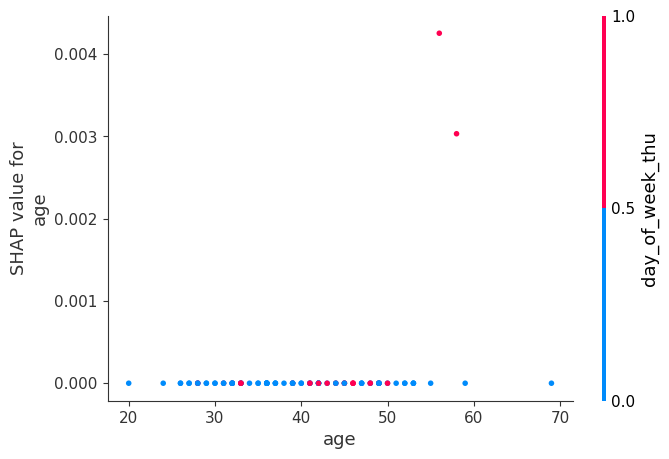

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

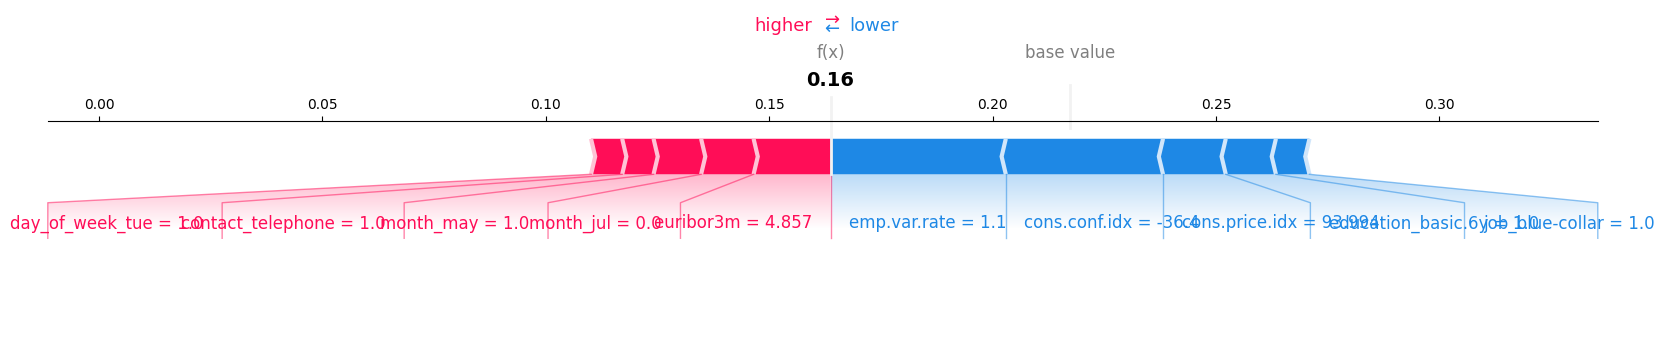

<Figure size 640x480 with 0 Axes>

In [20]:
import shap
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
print("\n  SHAP EXPLANATION ")
svm = CalibratedClassifierCV(best_model_LR)
svm.fit(X_train,y_train)
X_sample = X_train.sample(100,random_state=42)
# Create KernelExplainer
explainer = shap.KernelExplainer(svm.predict_proba,X_sample)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification → explain class 1
shap_vals = shap_values[:,:,1]

# Global Feature Importance
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")
plt.savefig("SHAP_Bar.png", bbox_inches="tight")
plt.show()

#  Detailed Summary Plot
plt.figure()
shap.summary_plot(shap_vals, X_sample)
plt.savefig("SHAP_Beeswarm.png", bbox_inches="tight")
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)
plt.savefig("SHAP_Dependence.png", bbox_inches="tight")
plt.show()

#  Force Plot (Single Prediction)

plt.figure()
shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_sample.iloc[0],
    matplotlib=True
)
plt.savefig("SHAP_Force.png", bbox_inches="tight")
plt.show()

LIME STARTED 
Model has no predict proba applying calibration .
Creating Local LIME...


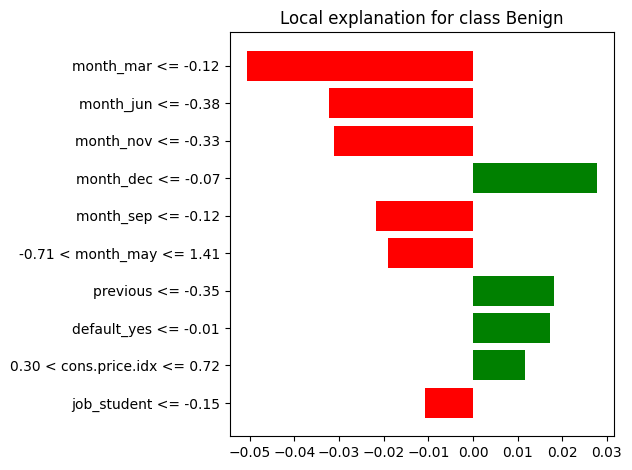

LIME COMPLETED 


In [21]:
from sklearn.preprocessing import StandardScaler
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("LIME STARTED ")
model_lime=best_model_LR
if not hasattr(model_lime,"predict_proba"):
    print("Model has no predict proba applying calibration .")
    model_lime=CalibratedClassifierCV(model_lime,method='sigmoid')
    model_lime.fit(X_train,y_train)
#  SCALE DATA (important for LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


#  CREATE LIME EXPLAINER
lime_explainer = LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X_train.columns.tolist(),
    class_names   = ['Malignant','Benign'],
    mode          = 'classification',
    discretize_continuous = True
)

#  LOCAL LIME (Single Prediction)
print("Creating Local LIME...")

i = 0   # first test row

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    model_lime.predict_proba,
    num_features = 10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("LIME_Local_RF.png", dpi=300)
plt.show()
print("LIME COMPLETED ")

In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (LinearSVC)
from sklearn.svm import LinearSVC
clf_name = "SVM"
clf = LinearSVC()


# Store results
results3 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results3.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results3_df3 = pd.DataFrame(results3)

# Print
print(f"Results for {clf_name}:")
print(results3_df3)

# Save to CSV if needed
results3_df3.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for SVM:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1        SVM  0.898034   0.712766  0.209375     0.988871  0.323671   
1      2        SVM  0.895849   0.647727  0.182692     0.987264  0.285000   
2      3        SVM  0.897669   0.627907  0.178218     0.986901  0.277635   
3      4        SVM  0.904588   0.747368  0.229773     0.990152  0.351485   
4      5        SVM  0.899490   0.691358  0.182410     0.989750  0.288660   
5      6        SVM  0.900583   0.646465  0.211921     0.985679  0.319202   
6      7        SVM  0.901311   0.602151  0.193103     0.984935  0.292428   
7      8        SVM  0.891843   0.714286  0.193452     0.989212  0.304450   
8      9        SVM  0.894028   0.720000  0.214925     0.988387  0.331034   
9     10        SVM  0.899490   0.652174  0.197368     0.986896  0.303030   
10    11        SVM  0.908230   0.723077  0.167260     0.992698  0.271676   
11    12        SVM  0.907502   0.729412  0.211604     0.99

In [23]:
# Model

from xgboost import XGBClassifier

model4 =  XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist5 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
            "max_depth": [3, 6]
}

In [24]:
# XGBoost

random_search = RandomizedSearchCV(model4, param_distributions=param_dist5, n_iter=100,
                                   cv=20, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Best CV accuracy: 0.8065
Test accuracy: 0.8944



SHAP EXPLANATION 


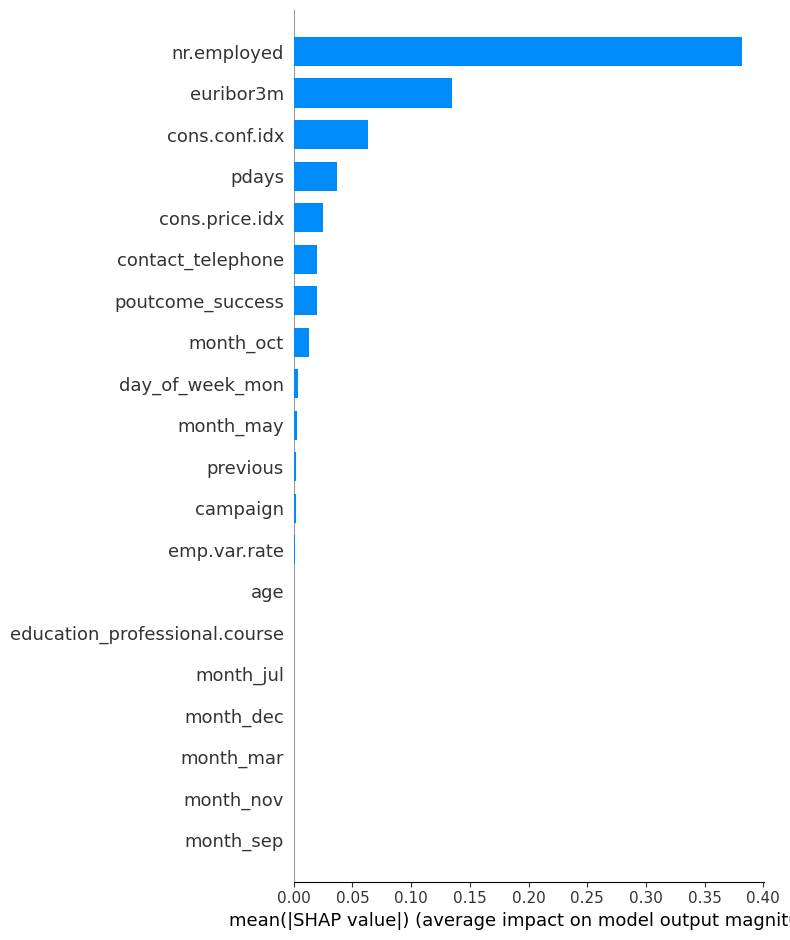

<Figure size 640x480 with 0 Axes>

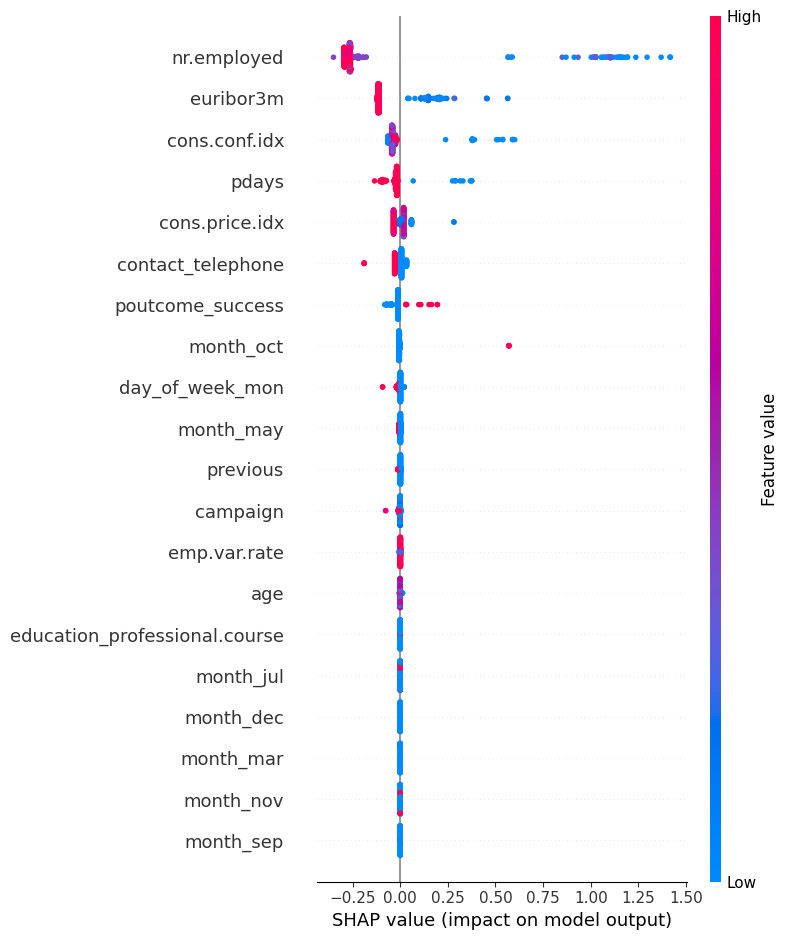

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

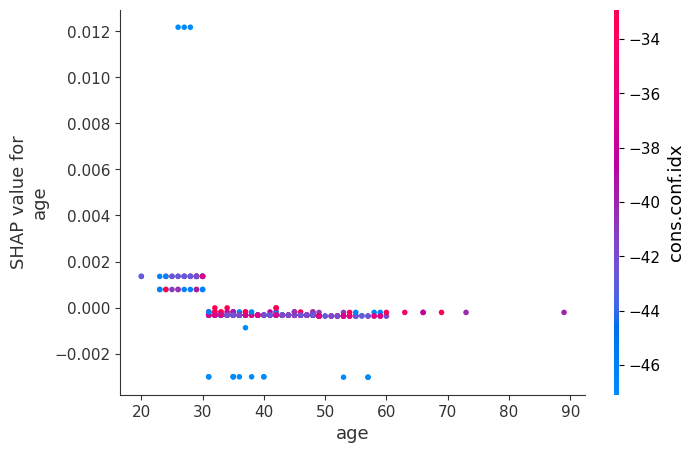

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

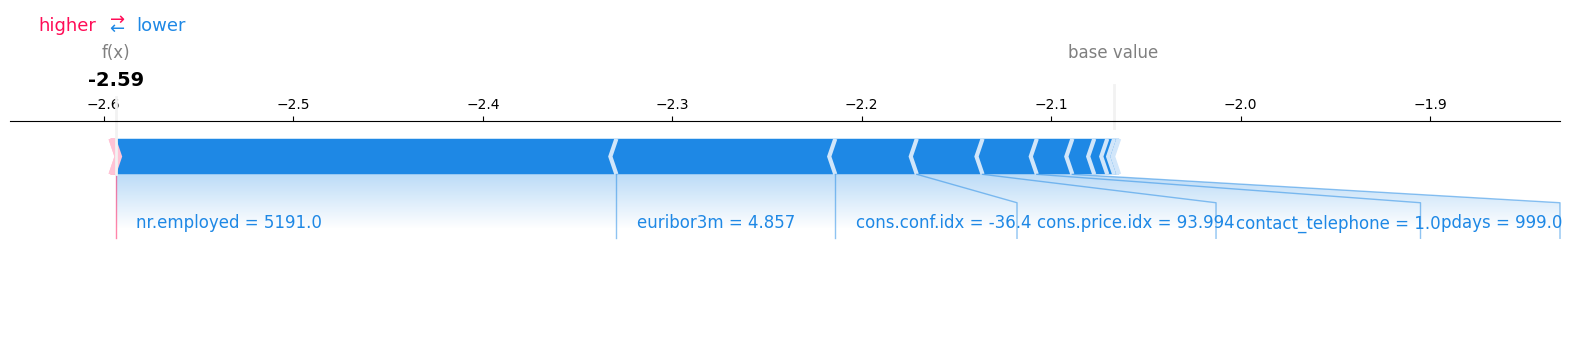

<Figure size 640x480 with 0 Axes>

In [25]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION ")

#  take small sample (SHAP is slow on full data)
X_sample = X_train.sample(300, random_state=42)

#  create explainer (new universal method)
explainer = shap.Explainer(best_model_LR)

#  generate SHAP values
shap_values = explainer(X_sample)

#  convert to correct matrix (binary classification → class 1)
if len(shap_values.values.shape)==3:
    shap_vals = shap_values.values[:,:, 1]
else:
    shap_vals = shap_values.values
#  Global Feature Importance (Bar)
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")
plt.savefig("SHAP_Bar.png", bbox_inches="tight")
plt.show()

#  Detailed Beeswarm Summary
plt.figure()
shap.summary_plot(shap_vals, X_sample)
plt.savefig("SHAP_Beeswarm.png", bbox_inches="tight")
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)
plt.savefig("SHAP_Dependence.png", bbox_inches="tight")
plt.show()

#  Force Plot (Single Prediction)

plt.figure()
shap.force_plot(
    explainer.expected_value,
    shap_vals[0],
    X_sample.iloc[0],
    matplotlib=True
)
plt.savefig("SHAP_Force.png", bbox_inches="tight")
plt.show()


LIME STARTED 
Creating Local LIME...


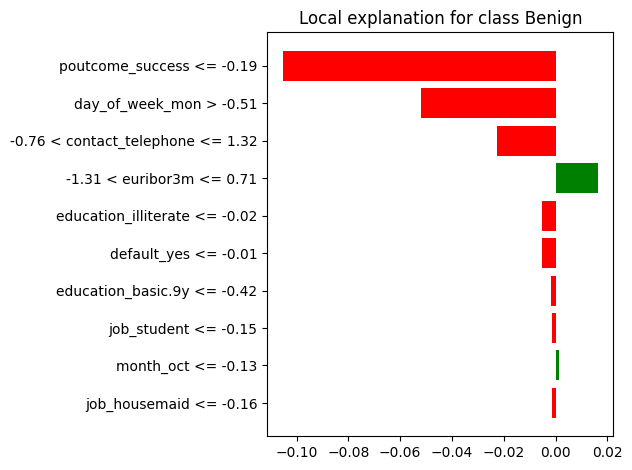

LIME COMPLETED 


In [26]:
from sklearn.preprocessing import StandardScaler
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("LIME STARTED ")

#  SCALE DATA (important for LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


#  CREATE LIME EXPLAINER
lime_explainer = LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X_train.columns.tolist(),
    class_names   = ['Malignant','Benign'],
    mode          = 'classification',
    discretize_continuous = True
)

#  LOCAL LIME (Single Prediction)
print("Creating Local LIME...")

i = 0   # first test row

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    best_model_LR.predict_proba,
    num_features = 10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("LIME_Local_RF.png", dpi=300)
plt.show()
print("LIME COMPLETED ")

In [28]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (XGBoost)
from xgboost import XGBClassifier
clf_name = "XGBoost"
clf =  XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Store results
results4 = []

# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results4.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results4_df4 = pd.DataFrame(results4)

# Print
print(f"Results for {clf_name}:")
print(results4_df4)

# Save to CSV if needed
results4_df4.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for XGBoost:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1    XGBoost  0.890386   0.559748  0.278125     0.971146  0.371608   
1      2    XGBoost  0.891843   0.551020  0.259615     0.972884  0.352941   
2      3    XGBoost  0.896941   0.571429  0.264026     0.975440  0.361174   
3      4    XGBoost  0.904953   0.671429  0.304207     0.981124  0.418708   
4      5    XGBoost  0.901311   0.625000  0.293160     0.977860  0.399113   
5      6    XGBoost  0.898034   0.568750  0.301325     0.971768  0.393939   
6      7    XGBoost  0.895484   0.509804  0.268966     0.969463  0.352144   
7      8    XGBoost  0.889658   0.610738  0.270833     0.975934  0.375258   
8      9    XGBoost  0.886016   0.572368  0.259701     0.973040  0.357290   
9     10    XGBoost  0.898034   0.593750  0.250000     0.978706  0.351852   
10    11    XGBoost  0.906409   0.592308  0.274021     0.978499  0.374696   
11    12    XGBoost  0.907138   0.631944  0.310580     

In [29]:
# Model LightGBM

model5 =  LGBMClassifier()

param_dist6 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1]
}

In [30]:
# LightGBM

random_search = RandomizedSearchCV(model5, param_distributions=param_dist6, n_iter=100,
                                   cv=25, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

[LightGBM] [Info] Number of positive: 4327, number of negative: 34116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 492
[LightGBM] [Info] Number of data points in the train set: 38443, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112556 -> initscore=-2.064892
[LightGBM] [Info] Start training from score -2.064892
Best parameters: {'n_estimators': 100, 'learning_rate': 0.01}
Best CV accuracy: 0.6616
Test accuracy: 0.8947



SHAP EXPLANATION 


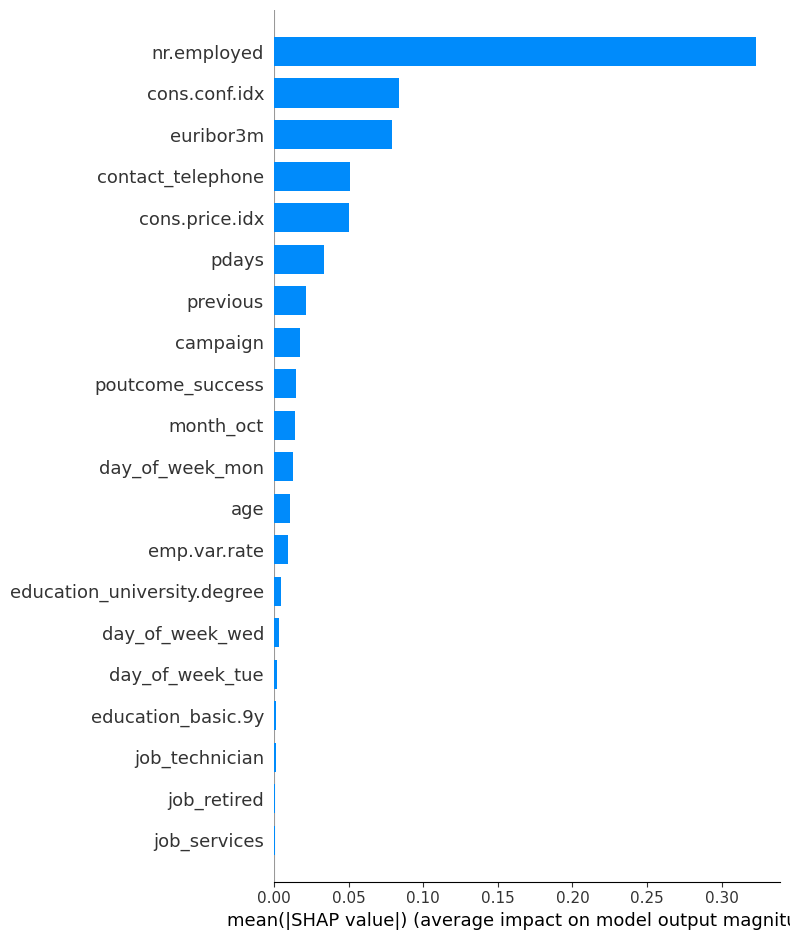

<Figure size 640x480 with 0 Axes>

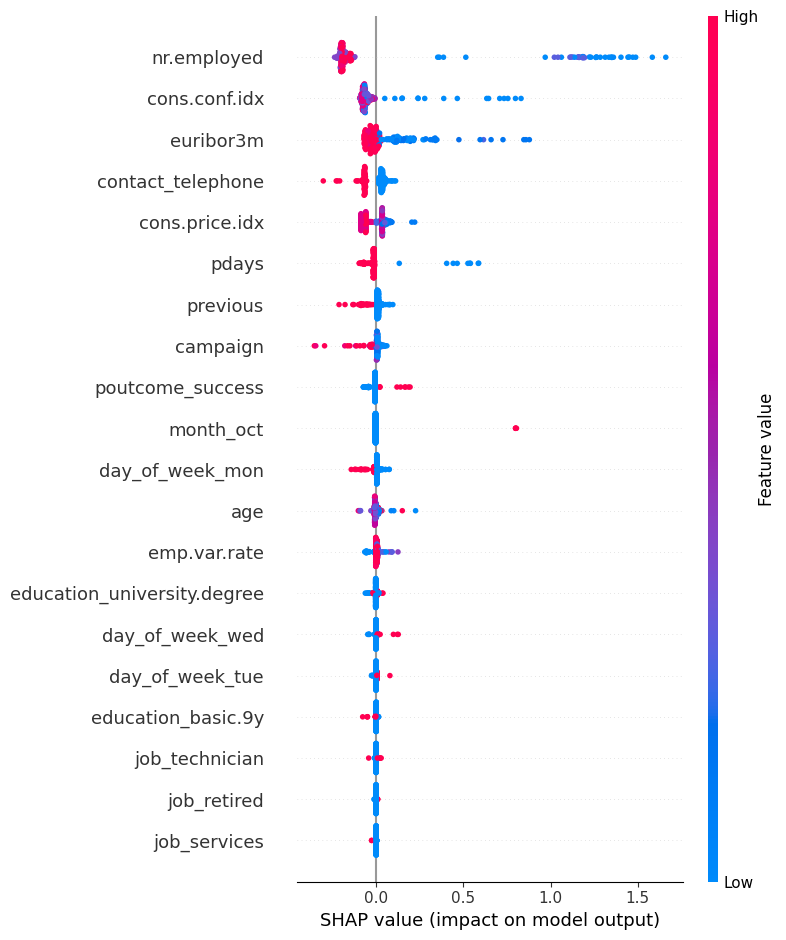

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

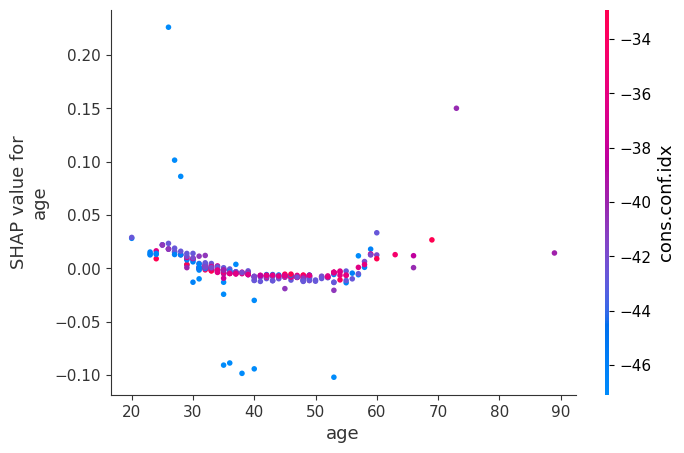

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

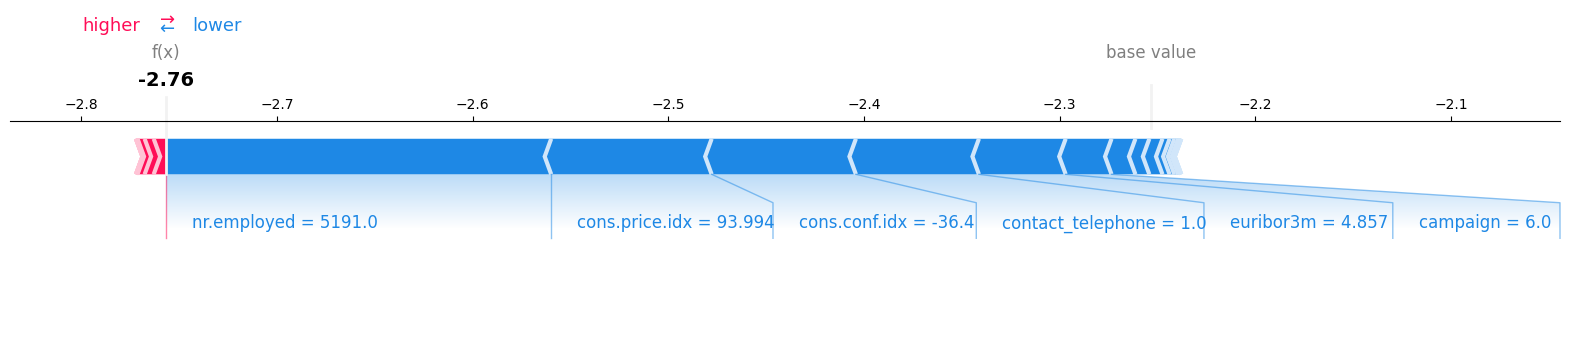

<Figure size 640x480 with 0 Axes>

In [31]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION ")

#  take small sample (SHAP is slow on full data)
X_sample = X_train.sample(300, random_state=42)

#  create explainer (new universal method)
explainer = shap.Explainer(best_model_LR)

#  generate SHAP values
shap_values = explainer(X_sample)

#  convert to correct matrix (binary classification → class 1)
if len(shap_values.values.shape)==3:
    shap_vals = shap_values.values[:,:, 1]
else:
    shap_vals = shap_values.values
#  Global Feature Importance (Bar)
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")
plt.savefig("SHAP_Bar.png", bbox_inches="tight")
plt.show()

#  Detailed Beeswarm Summary
plt.figure()
shap.summary_plot(shap_vals, X_sample)
plt.savefig("SHAP_Beeswarm.png", bbox_inches="tight")
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)
plt.savefig("SHAP_Dependence.png", bbox_inches="tight")
plt.show()

#  Force Plot (Single Prediction)
plt.figure()
shap.force_plot(
    explainer.expected_value,
    shap_vals[0],
    X_sample.iloc[0],
    matplotlib=True
)
plt.savefig("SHAP_Force.png", bbox_inches="tight")
plt.show()

LIME STARTED 
Creating Local LIME...


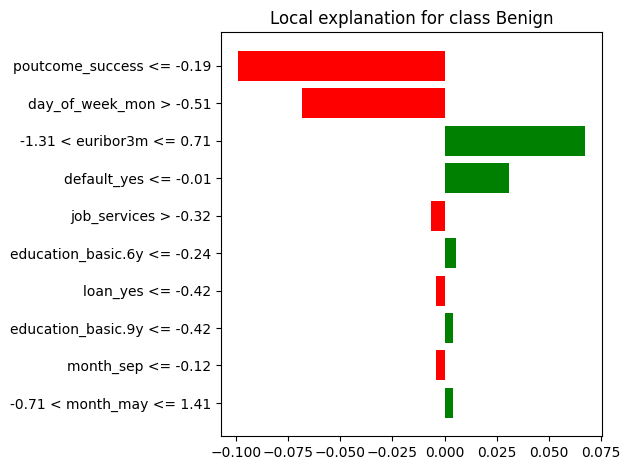

LIME COMPLETED 


In [32]:
from sklearn.preprocessing import StandardScaler
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("LIME STARTED ")

#  SCALE DATA (important for LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


#  CREATE LIME EXPLAINER
lime_explainer = LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X_train.columns.tolist(),
    class_names   = ['Malignant','Benign'],
    mode          = 'classification',
    discretize_continuous = True
)

#  LOCAL LIME (Single Prediction)
print("Creating Local LIME...")

i = 0   # first test row

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    best_model_LR.predict_proba,
    num_features = 10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("LIME_Local_RF.png", dpi=300)
plt.show()
print("LIME COMPLETED ")

In [33]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (XGBoost)
from lightgbm import LGBMClassifier
clf_name = "LightGBM"
clf =  LGBMClassifier()


# Store results
results5 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results5.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results5_df5 = pd.DataFrame(results5)

# Print
print(f"Results for {clf_name}:")
print(results5_df5)

# Save to CSV if needed
results5_df5.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

[LightGBM] [Info] Number of positive: 4320, number of negative: 34122
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 38442, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112377 -> initscore=-2.066687
[LightGBM] [Info] Start training from score -2.066687
[LightGBM] [Info] Number of positive: 4328, number of negative: 34114
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 38442, number of used features: 44
[LightGBM] [Info] [bin

In [34]:
from scipy.stats import wilcoxon
import pandas as pd
import itertools

print("\nWILCOXON SIGNED-RANK TEST")

#  Create ONE master dataframe (paired folds)
acc_df = pd.DataFrame({
    "Random Forest": results1_df1["Accuracy"].reset_index(drop=True),
    "KNN": results2_df2["Accuracy"].reset_index(drop=True),
    "SVM": results3_df3["Accuracy"].reset_index(drop=True),
    "XGBoost": results4_df4["Accuracy"].reset_index(drop=True),
    "LightGBM": results5_df5["Accuracy"].reset_index(drop=True),
})

#  Remove rows with missing folds (VERY IMPORTANT)
acc_df = acc_df.dropna()
print("Paired dataset shape:", acc_df.shape)

#  Pairwise Wilcoxon test
wilcoxon_results = []

for m1, m2 in itertools.combinations(acc_df.columns, 2):
    
    arr1 = acc_df[m1].values
    arr2 = acc_df[m2].values
    
    stat, p = wilcoxon(arr1, arr2) 
    
    wilcoxon_results.append([m1, m2, stat, p])

#  Result table
wilcoxon_df = pd.DataFrame(
    wilcoxon_results,
    columns=["Model 1", "Model 2", "Statistic", "p-value"]
)

wilcoxon_df["Significant (p<0.05)"] = wilcoxon_df["p-value"] < 0.05

print(wilcoxon_df)

#  Save for research paper
wilcoxon_df.to_excel("Wilcoxon_Test5.xlsx", index=False)

print("Wilcoxon test completed successfully ")


WILCOXON SIGNED-RANK TEST
Paired dataset shape: (10, 5)
         Model 1   Model 2  Statistic   p-value  Significant (p<0.05)
0  Random Forest       KNN       19.0  0.431641                 False
1  Random Forest       SVM        5.0  0.019531                  True
2  Random Forest   XGBoost       17.0  0.322266                 False
3  Random Forest  LightGBM        1.0  0.003906                  True
4            KNN       SVM        0.0  0.001953                  True
5            KNN   XGBoost        3.0  0.009766                  True
6            KNN  LightGBM        0.0  0.001953                  True
7            SVM   XGBoost        5.0  0.019531                  True
8            SVM  LightGBM       17.0  0.306641                 False
9        XGBoost  LightGBM        0.0  0.001953                  True
Wilcoxon test completed successfully 


In [35]:
summary = pd.DataFrame({
    "Models":[
        "Random Forest","KNN","SVM","XGBoost","LightGBM"],
    "Accuracy":[
        results1_df1["Accuracy"].mean(),
        results2_df2["Accuracy"].mean(),
        results3_df3["Accuracy"].mean(),
        results4_df4["Accuracy"].mean(),
        results5_df5["Accuracy"].mean()
    ],
    "Precision":[
        results1_df1["Precision"].mean(),
        results2_df2["Precision"].mean(),
        results3_df3["Precision"].mean(),
        results4_df4["Precision"].mean(),
        results5_df5["Precision"].mean()
    ],
    "Recall":[
        results1_df1["Recall"].mean(),
        results2_df2["Recall"].mean(),
        results3_df3["Recall"].mean(),
        results4_df4["Recall"].mean(),
        results5_df5["Recall"].mean()
    ],
    "F1":[
        results1_df1["F1"].mean(),
        results2_df2["F1"].mean(),
        results3_df3["F1"].mean(),
        results4_df4["F1"].mean(),
        results5_df5["F1"].mean()
    ],
    "AUC":[
        results1_df1["AUC"].mean(),
        results2_df2["AUC"].mean(),
        results3_df3["AUC"].mean(),
        results4_df4["AUC"].mean(),
        results5_df5["AUC"].mean()
    ],
    "Training Time":[
        results1_df1["Training Time (s)"].mean(),
        results2_df2["Training Time (s)"].mean(),
        results3_df3["Training Time (s)"].mean(),
        results4_df4["Training Time (s)"].mean(),
        results5_df5["Training Time (s)"].mean()
    ]
})

print(summary)

          Models  Accuracy  Precision    Recall        F1       AUC  \
0  Random Forest  0.891352   0.532821  0.288287  0.373687  0.628079   
1            KNN  0.890138   0.522389  0.289196  0.371852  0.627813   
2            SVM  0.899679   0.696082  0.195231  0.304341  0.592158   
3        XGBoost  0.897446   0.595768  0.281162  0.381647  0.628432   
4       LightGBM  0.900238   0.634629  0.269816  0.378255  0.625045   

   Training Time  
0       4.213942  
1       0.031020  
2       0.274486  
3       0.729609  
4       0.279378  


In [36]:
import numpy as np

print("\nTOPSIS RANKING")

# remove model column
data = summary.drop("Models", axis=1).values

# Step 1: Normalize matrix
norm = data / np.sqrt((data**2).sum(axis=0))

# Step 2: Weights (equal weights)
weights = np.ones(norm.shape[1]) / norm.shape[1]
weighted = norm * weights

# Step 3: Ideal best & worst
# Benefit metrics: Accuracy, Precision, Recall, F1, AUC → MAX
# Cost metric: Training Time → MIN

ideal_best = np.max(weighted, axis=0)
ideal_worst = np.min(weighted, axis=0)

# For Training Time column (last column) reverse
ideal_best[-1] = np.min(weighted[:, -1])
ideal_worst[-1] = np.max(weighted[:, -1])

# Step 4: Distance to ideal solutions
dist_best = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
dist_worst = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

# Step 5: TOPSIS score
topsis_score = dist_worst / (dist_best + dist_worst)

summary["TOPSIS Score"] = topsis_score
summary["Rank"] = summary["TOPSIS Score"].rank(ascending=False)

summary = summary.sort_values("Rank")

print(summary)

summary.to_excel("TOPSIS_Ranking5.xlsx", index=False)


TOPSIS RANKING
          Models  Accuracy  Precision    Recall        F1       AUC  \
4       LightGBM  0.900238   0.634629  0.269816  0.378255  0.625045   
1            KNN  0.890138   0.522389  0.289196  0.371852  0.627813   
2            SVM  0.899679   0.696082  0.195231  0.304341  0.592158   
3        XGBoost  0.897446   0.595768  0.281162  0.381647  0.628432   
0  Random Forest  0.891352   0.532821  0.288287  0.373687  0.628079   

   Training Time  TOPSIS Score  Rank  
4       0.279378      0.920363   1.0  
1       0.031020      0.883850   2.0  
2       0.274486      0.826698   3.0  
3       0.729609      0.822448   4.0  
0       4.213942      0.154756   5.0  


In [37]:
models_results5 = {
    "Random Forest": results1_df1,
    "KNN": results2_df2,
    "SVM": results3_df3,
    "XGBoost": results4_df4,
    "LightGBM": results5_df5
}

In [38]:
metrics = [
    "Accuracy","Precision","Recall","Specificity",
    "F1","GM","FPR","AUC","MCC","Kappa",
    "Balanced Accuracy","Training Time (s)"
]

In [39]:
print("Creating FINAL Excel file...")

with pd.ExcelWriter("Final_Results_best5.xlsx") as writer:

    # Loop through each metric → each becomes a sheet
    for metric in metrics:
        
        metric_df = pd.DataFrame()

        # Collect metric from every model
        for model_name, df in models_results5.items():
            metric_df[model_name] = df[metric].reset_index(drop=True)

        # Add fold column (1–10)
        metric_df.insert(0, "Fold", range(1, len(metric_df)+1))

        # Save sheet
        metric_df.to_excel(writer, sheet_name=metric, index=False)

print("Excel file created successfully ")

Creating FINAL Excel file...
Excel file created successfully 
